In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
%matplotlib inline
import seaborn as sns

In [6]:
df = pd.read_csv('Diwali Sales Data.csv',encoding = 'unicode_escape')

In [7]:
df.head(10)

,User_ID,Cust_name,Product_ID,Gender,Age Group,Age,Marital_Status,State,Zone,Occupation,Product_Category,Orders,Amount,Status,unnamed1
0,1002903,Sanskriti,P00125942,F,26-35,28,0,Maharashtra,Western,Healthcare,Auto,1,23952.00,NaN,NaN
1,1000732,Kartik,P00110942,F,26-35,35,1,Andhra Pradesh,Southern,Govt,Auto,3,23934.00,NaN,NaN
2,1001990,Bindu,P00118542,F,26-35,35,1,Uttar Pradesh,Central,Automobile,Auto,3,23924.00,NaN,NaN
3,1001425,Sudevi,P00237842,M,0-17,16,0,Karnataka,Southern,Construction,Auto,2,23912.00,NaN,NaN
4,1000588,Joni,P00057942,M,26-35,28,1,Gujarat,Western,Food Processing,Auto,2,23877.00,NaN,NaN
5,1000588,Joni,P00057942,M,26-35,28,1,Himachal Pradesh,Northern,Food Processing,Auto,1,23877.00,NaN,NaN
6,1001132,Balk,P00018042,F,18-25,25,1,Uttar Pradesh,Central,Lawyer,Auto,4,23841.00,NaN,NaN
7,1002092,Shivangi,P00273442,F,55+,61,0,Maharashtra,Western,IT Sector,Auto,1,NaN,NaN,NaN
8,1003224,Kushal,P00205642,M,26-35,35,0,Uttar Pradesh,Central,Govt,Auto,2,23809.00,NaN,NaN
9,1003650,Ginny,P00031142,F,26-35,26,1,Andhra Pradesh,Southern,Media,Auto,4,23799.99,NaN,NaN


In [9]:
# Data Cleaning

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11251 entries, 0 to 11250
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   User_ID           11251 non-null  int64  
 1   Cust_name         11251 non-null  object 
 2   Product_ID        11251 non-null  object 
 3   Gender            11251 non-null  object 
 4   Age Group         11251 non-null  object 
 5   Age               11251 non-null  int64  
 6   Marital_Status    11251 non-null  int64  
 7   State             11251 non-null  object 
 8   Zone              11251 non-null  object 
 9   Occupation        11251 non-null  object 
 10  Product_Category  11251 non-null  object 
 11  Orders            11251 non-null  int64  
 12  Amount            11239 non-null  float64
 13  Status            0 non-null      float64
 14  unnamed1          0 non-null      float64
dtypes: float64(3), int64(4), object(8)
memory usage: 1.3+ MB


In [11]:
# drop blank/unrelated columns
df.drop(['Status','unnamed1'], axis=1 ,inplace= True)

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11251 entries, 0 to 11250
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   User_ID           11251 non-null  int64  
 1   Cust_name         11251 non-null  object 
 2   Product_ID        11251 non-null  object 
 3   Gender            11251 non-null  object 
 4   Age Group         11251 non-null  object 
 5   Age               11251 non-null  int64  
 6   Marital_Status    11251 non-null  int64  
 7   State             11251 non-null  object 
 8   Zone              11251 non-null  object 
 9   Occupation        11251 non-null  object 
 10  Product_Category  11251 non-null  object 
 11  Orders            11251 non-null  int64  
 12  Amount            11239 non-null  float64
dtypes: float64(1), int64(4), object(8)
memory usage: 1.1+ MB


In [35]:
df = df.apply(lambda x: x.str.strip() if x.dtype == "object" else x)

In [15]:
df.isnull().sum()

User_ID              0
Cust_name            0
Product_ID           0
Gender               0
Age Group            0
Age                  0
Marital_Status       0
State                0
Zone                 0
Occupation           0
Product_Category     0
Orders               0
Amount              12
dtype: int64

In [16]:
df.dropna(inplace= True)

In [17]:
df['Amount'] = df ['Amount'].astype('int')

In [18]:
df['Amount'].dtypes


dtype('int64')

In [20]:
df[['Age','Orders','Amount']].describe()

,Age,Orders,Amount
count,11239.000000,11239.000000,11239.000000
mean,35.410357,2.489634,9453.610553
std,12.753866,1.114967,5222.355168
min,12.000000,1.000000,188.000000
25%,27.000000,2.000000,5443.000000
50%,33.000000,2.000000,8109.000000
75%,43.000000,3.000000,12675.000000
max,92.000000,4.000000,23952.000000


 min amount is 188 and max amount is 23952

In [21]:
# EDA

In [23]:
df.columns

Index(['User_ID', 'Cust_name', 'Product_ID', 'Gender', 'Age Group', 'Age',
       'Marital_Status', 'State', 'Zone', 'Occupation', 'Product_Category',
       'Orders', 'Amount'],
      dtype='object')

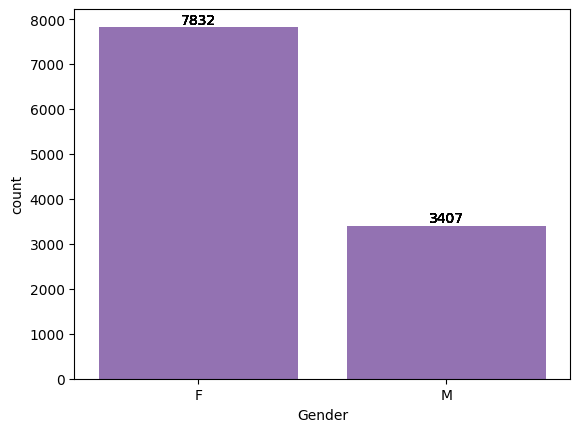

In [28]:
#GENDER
ax = sns.countplot( x= 'Gender' , data =df)

for bars in ax.containers:
    ax.bar_label(bars)

plt.show()

Most buyers are female and purchasing power of female is also greater than men


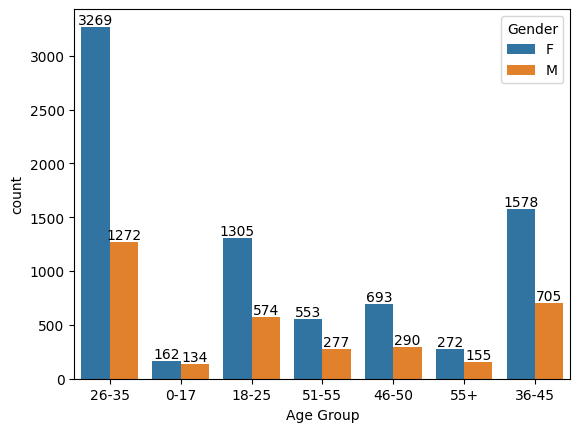

In [36]:
#AGE
ax = sns.countplot(x = 'Age Group', hue = 'Gender',data = df)

for bars in ax.containers:
    ax.bar_label(bars)

plt.show()

From this we can say females especially from age group of 26-35 are more into shopping

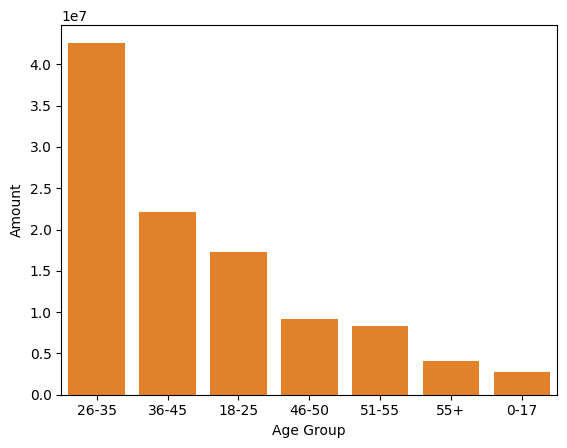

In [41]:
#Total Amount VS Age Group
sales_age= df.groupby(['Age Group'],as_index=False)['Amount'].sum().sort_values(by= 'Amount', ascending = False)

sns.barplot(x='Age Group',y='Amount', data= sales_age)
plt.show()

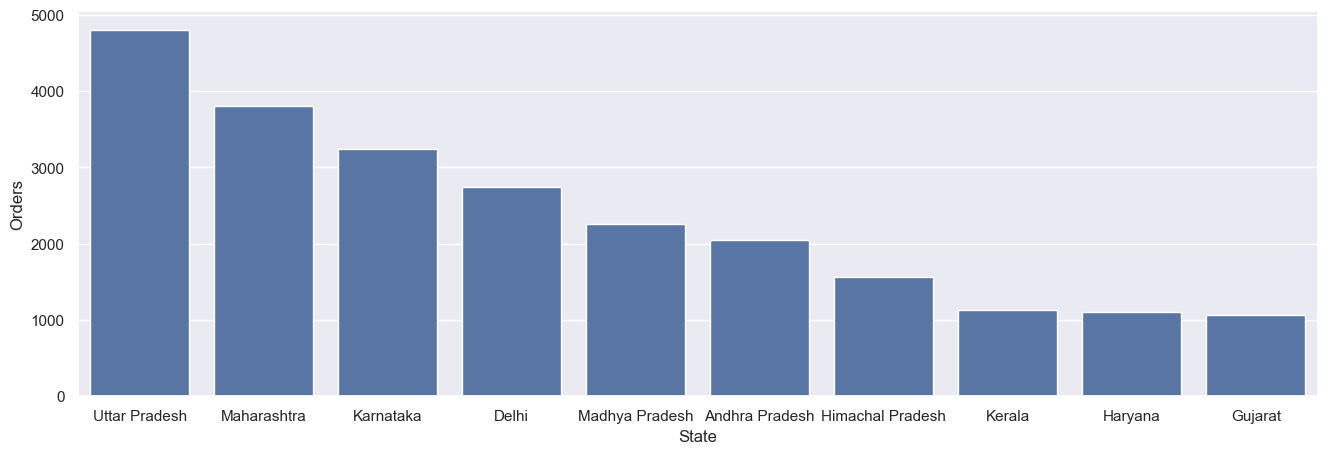

In [55]:
#Total number of orders from top 10 states
sales_state= df.groupby(['State'],as_index= False)['Orders'].sum().sort_values(by = 'Orders' ,ascending= False).head(10)

sns.set(rc={'figure.figsize':(16,5)})
sns.barplot(data =sales_state ,x = 'State', y='Orders')
plt.show()

Most of the orders are from Uttar pradesh ,Maharashtra, Karnatka

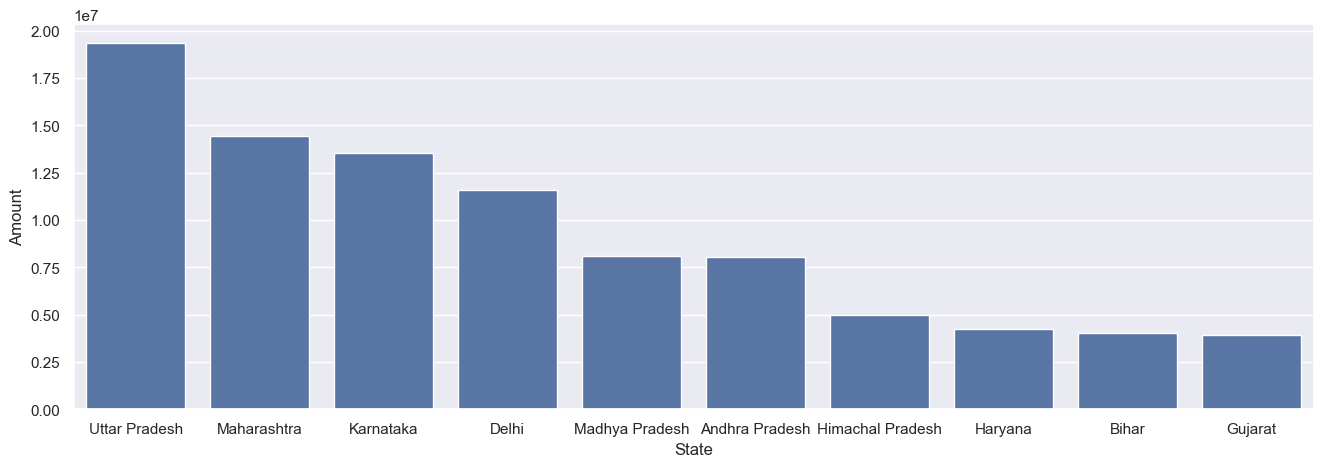

In [57]:
#Total sales from top 10 States
sales_state= df.groupby(['State'],as_index= False)['Amount'].sum().sort_values(by = 'Amount' ,ascending= False).head(10)

sns.set(rc={'figure.figsize':(16,5)})
sns.barplot(data =sales_state ,y = 'Amount', x='State')
plt.show()

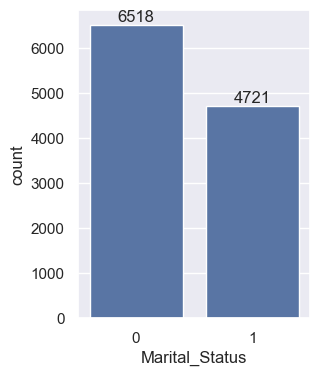

In [65]:
#Marital Status

ax= sns.countplot(data=df,x='Marital_Status')

sns.set(rc={'figure.figsize':(3,6)})
for bars in ax.containers:
    ax.bar_label(bars)

plt.show()


Married persons have higher purchasing power

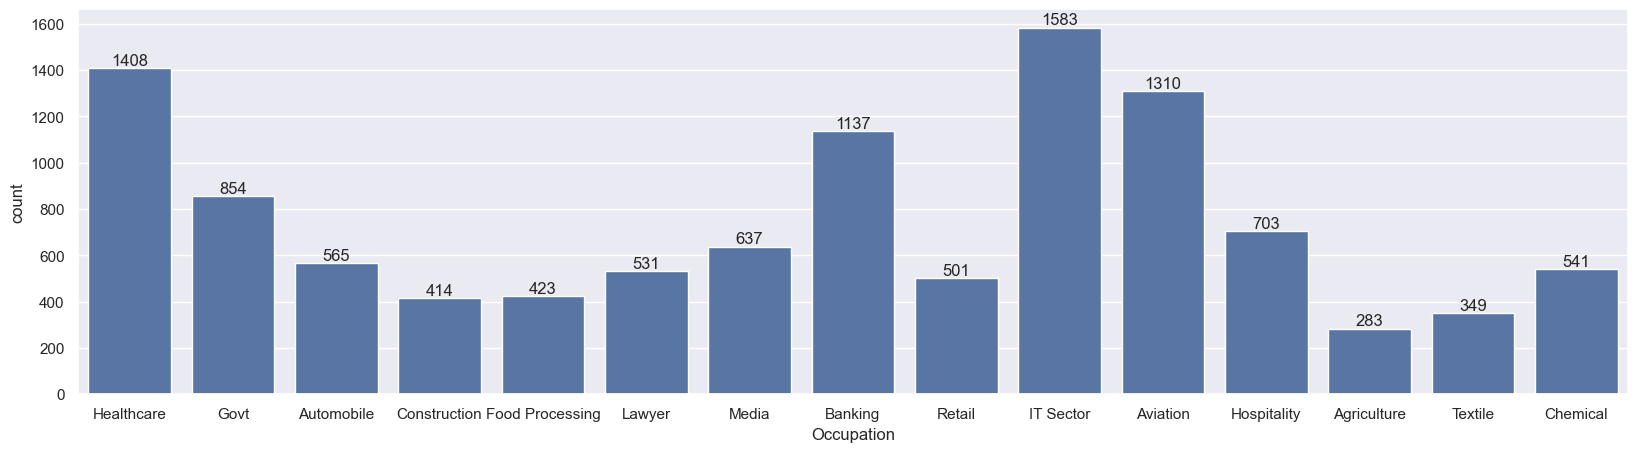

In [67]:
#Occupation
sns.set(rc={'figure.figsize':(20,5)})
ax= sns.countplot(data = df, x= 'Occupation')

for bars in ax.containers:
    ax.bar_label(bars)
plt.show()

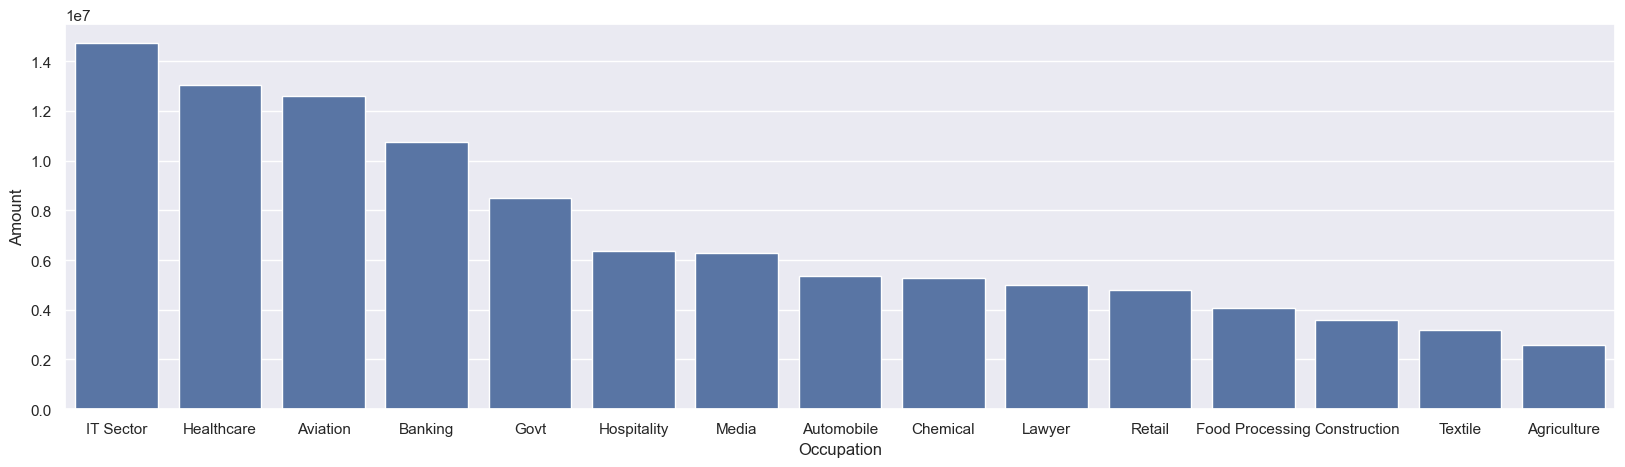

In [75]:
sales_state= df.groupby(['Occupation'],as_index= False)['Amount'].sum().sort_values(by = 'Amount' ,ascending= False)
                                                                                    

sns.set(rc={'figure.figsize':(20,5)})
sns.barplot(data =sales_state, x= 'Occupation',y= 'Amount')
plt.show()

We can say that the most of the buyers are working in IT,Healthcare and Aviation sector

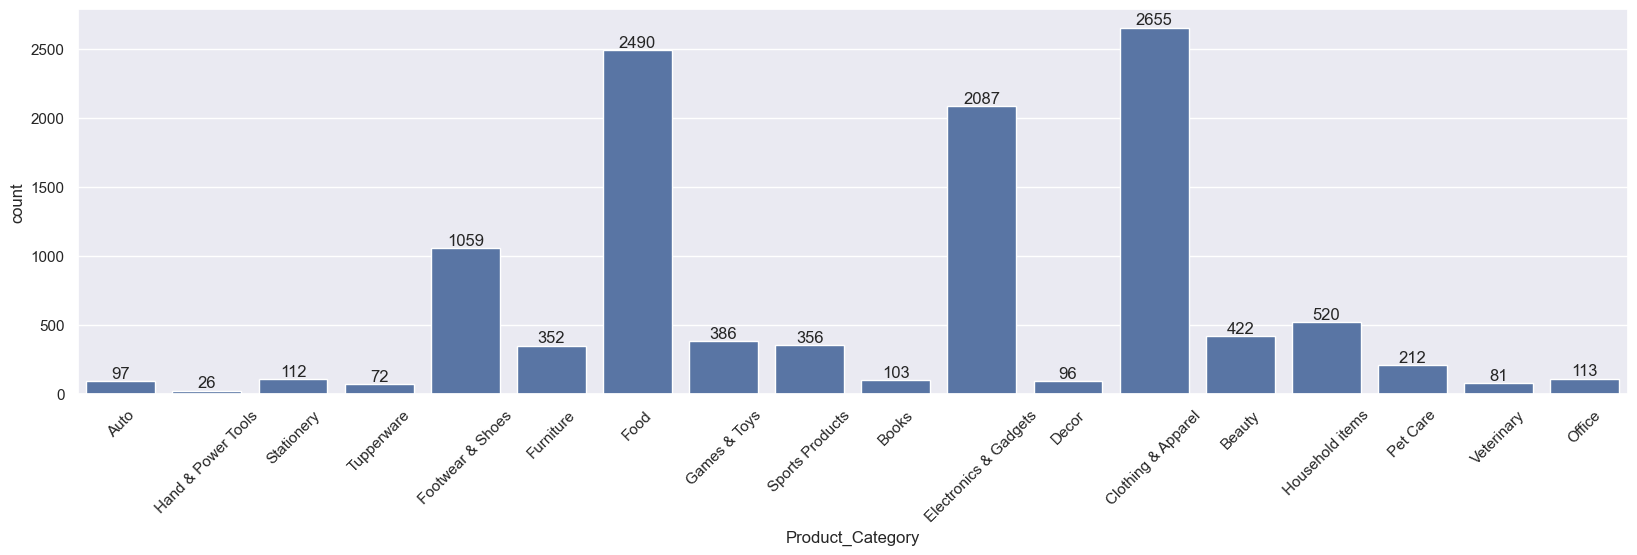

In [80]:
#Product category
sns.set(rc={'figure.figsize':(20,5)})
ax = sns.countplot(data =df, x= 'Product_Category')

for bars in ax.containers:
    ax.bar_label(bars)
plt.xticks(rotation=45)
plt.show()

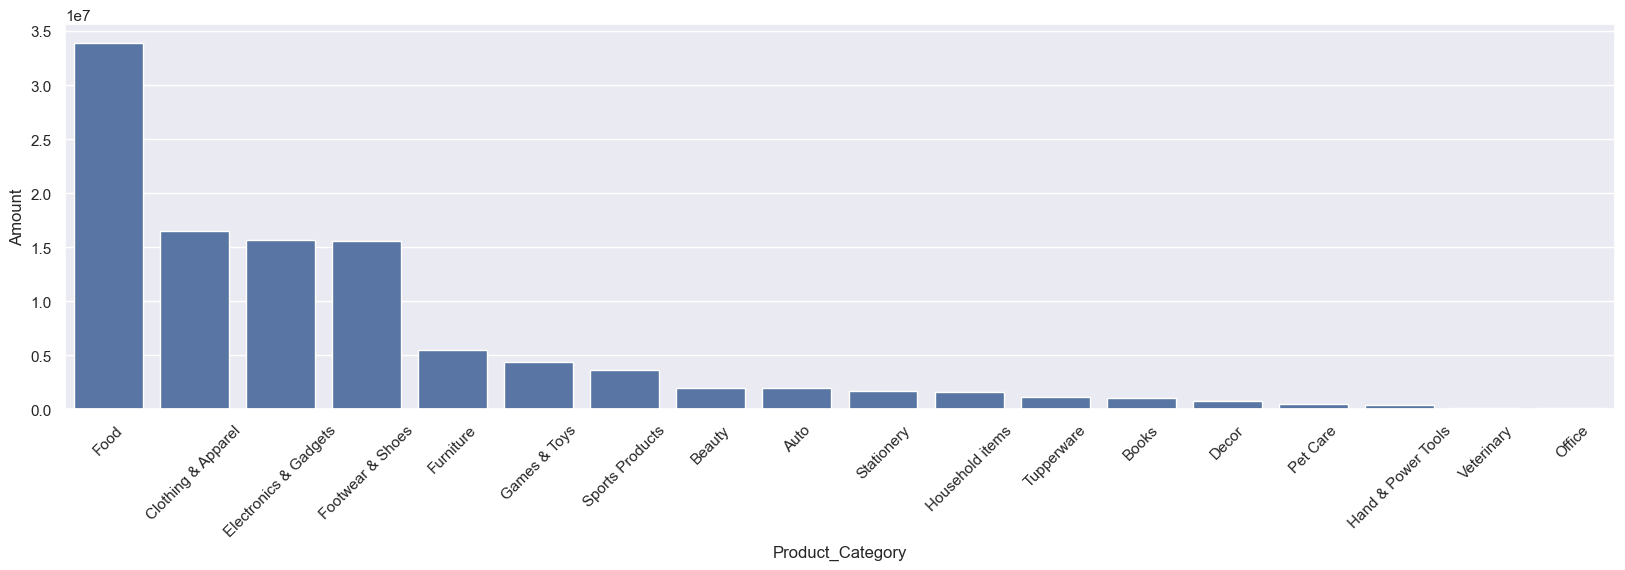

In [84]:
ax= df.groupby(['Product_Category'],as_index= False)['Amount'].sum().sort_values(by = 'Amount' ,ascending= False)
                                                                                    

sns.set(rc={'figure.figsize':(20,5)})
sns.barplot(data =ax, x= 'Product_Category',y= 'Amount')
plt.xticks(rotation=45)
plt.show()

we can say that most of the sold products are from food,clothing and apparel and electronic category

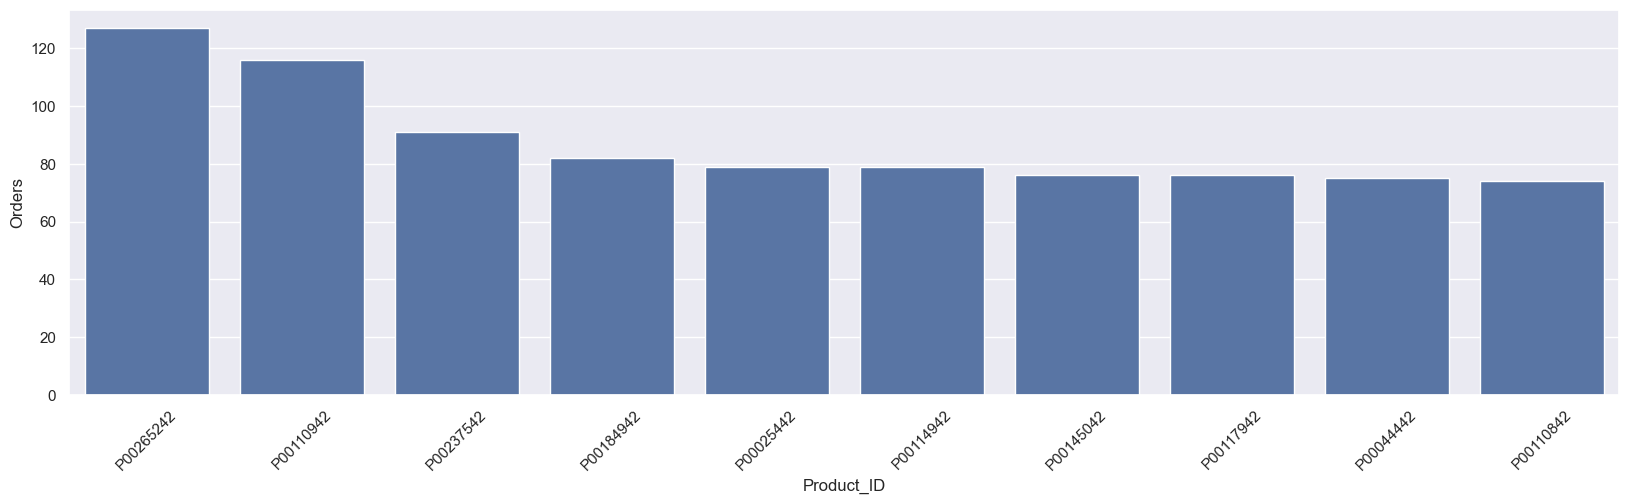

In [87]:
ax= df.groupby(['Product_ID'],as_index= False)['Orders'].sum().sort_values(by ='Orders' ,ascending= False).head(10)
                                                                                    

sns.set(rc={'figure.figsize':(20,5)})
sns.barplot(data =ax, x= 'Product_ID',y= 'Orders')
plt.xticks(rotation=45)
plt.show()

These are the top 10 selling products

#Counclusion:

Married women in the 26-35 age group from UP, Maharastra, and Karnataka working in IT, Healthcare, and Aviation are more likely to buy products from Food, Clothing, and Electronics categories.